In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# SAM 3 Agent

This notebook shows an example of how an MLLM can use SAM 3 as a tool, i.e., "SAM 3 Agent", to segment more complex text queries such as "the leftmost child wearing blue vest".

## Env Setup

First install `sam3` in your environment using the [installation instructions](https://github.com/facebookresearch/sam3?tab=readme-ov-file#installation) in the repository.

In [2]:
import torch
# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook. If your card doesn't support it, try float16 instead
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# inference mode for the whole notebook. Disable if you need gradients
torch.inference_mode().__enter__()

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [3]:
import os
import shutil

SAM3_ROOT = os.path.expanduser("~/run/JiaBSH/sam3")
if not os.path.isdir(SAM3_ROOT):
    raise FileNotFoundError(f"SAM3_ROOT does not exist: {SAM3_ROOT}")

print(f"Changing working directory to {SAM3_ROOT}")
os.chdir(SAM3_ROOT)

# setup GPU to use - a single GPU is enough for this demo
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
if shutil.which("nvidia-smi") is not None:
    _ = os.system("nvidia-smi")
else:
    print("nvidia-smi not found; skipping GPU status check")

Changing working directory to /data/home/scvi576/run/JiaBSH/sam3
Wed May 20 08:53:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:16:00.0 Off |                  N/A |
|  0%   31C    P8              7W /  600W |       3MiB /  32607MiB |      0%      Default |
|                                         |                        |       

## Build SAM3 Model

In [4]:
import sam3
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

sam3_root = os.path.dirname(sam3.__file__)
ckpt = "/data/home/scvi576/run/JiaBSH/sam3/ms_cache/facebook/sam3/sam3.pt" # <-- change to your local file

model = build_sam3_image_model(
    checkpoint_path=ckpt,
    load_from_HF=False,
    device="cuda" if torch.cuda.is_available() else "cpu",
    eval_mode=True,
)
processor = Sam3Processor(model, confidence_threshold=0.5)

/data/run01/scvi576/envs/sam3/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## LLM Setup

Config which MLLM to use, it can either be a model served by vLLM that you launch from your own machine or a model is served via external API. If you want to using a vLLM model, we also provided insturctions below.

In [5]:
LLM_CONFIGS = {
   
    "qwen3.5-flash": {
        "provider": "dashscope",
        "base_url": "https://dashscope.aliyuncs.com/compatible-mode/v1"
    },
    # models served via external APIs
    # add your own
}

model = "qwen3.5-flash"
LLM_API_KEY = 'sk-ee6ba686614c4bd89768324ce4163f5a'

llm_config = LLM_CONFIGS[model]
llm_config["api_key"] = LLM_API_KEY
llm_config["name"] = model
llm_config["model"] = model  # keep both keys for compatibility with downstream calls

# setup API endpoint
if llm_config["provider"] == "vllm":
    LLM_SERVER_URL = "http://0.0.0.0:8001/v1"  # replace this with your vLLM server address as needed
else:
    LLM_SERVER_URL = llm_config["base_url"]

### Setup vLLM server 
This step is only required if you are using a model served by vLLM, skip this step if you are calling LLM using an API like Gemini and GPT.

* Install vLLM (in a separate conda env from SAM 3 to avoid dependency conflicts).
  ```bash
    conda create -n vllm python=3.12
    pip install vllm --extra-index-url https://download.pytorch.org/whl/cu128
  ```
* Start vLLM server on the same machine of this notebook
  ```bash
    # qwen 3 VL 8B thinking
    vllm serve Qwen/Qwen3-VL-8B-Thinking --tensor-parallel-size 4 --allowed-local-media-path / --enforce-eager --port 8001
  ```

## Run SAM3 Agent Batch Evaluation

In [ ]:
from datetime import datetime
from functools import partial
from pathlib import Path
import json
import shutil
import time

import pandas as pd
from IPython.display import display, Image

from cus_tools.sam3_agent_eval_utils import (
    build_coco_ground_truth,
    compute_pixel_mask_metrics,
    evaluate_coco_predictions,
    expected_agent_paths,
    load_agent_prediction_as_coco,
    save_profile_artifacts,
)
from sam3.agent.client_llm import send_generate_request as send_generate_request_orig
from sam3.agent.client_sam3 import call_sam_service as call_sam_service_orig
from sam3.agent.inference import run_single_image_inference

In [ ]:
# Batch evaluation config
DATASET_ROOT = Path("mmdata_test_1024/50x")
IMAGE_DIR = DATASET_ROOT / "image"
LABEL_DIR = DATASET_ROOT / "label"
TEXT_PROMPT = "识别出图像中的所有石墨烯畴区，每个石墨烯畴区都是六边形，特别注意多个石墨烯畴区可能会重叠在一起，你需要将他们区分成多个实例"
SPLIT_NAME = "50x_unsup"
EVAL_MODE = "plain"
DEBUG_AGENT = True
SHOW_IMAGE_VISUALIZATION = True
APPEND_TO_SUMMARY_CSV = True
MAX_AGENT_RETRIES = 3
RETRY_WAIT_SECONDS = 0.0
RAISE_ON_IMAGE_FAILURE = False

if not IMAGE_DIR.is_dir() or not LABEL_DIR.is_dir():
    raise FileNotFoundError(f"Dataset folders are missing under {DATASET_ROOT}")

selected_model = llm_config.get("model", llm_config.get("name"))
if selected_model is None:
    raise KeyError("llm_config must contain either 'model' or 'name'")

send_generate_request = partial(
    send_generate_request_orig,
    server_url=LLM_SERVER_URL,
    model=selected_model,
    api_key=llm_config["api_key"],
)
call_sam_service = partial(call_sam_service_orig, sam3_processor=processor)

EVAL_MODEL_NAME = f"sam3_agent_{selected_model}"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = Path("outputs") / "coco_eval" / SPLIT_NAME / EVAL_MODE / EVAL_MODEL_NAME / RUN_TIMESTAMP
AGENT_OUTPUT_DIR = RUN_DIR / "agent_output"
VIS_DIR = RUN_DIR / "vis"
PROFILE_DIR = RUN_DIR / "profile"
GT_JSON_PATH = RUN_DIR / "gt_coco.json"
PREDICTIONS_JSON_PATH = RUN_DIR / "predictions.json"
METRICS_JSON_PATH = RUN_DIR / f"{RUN_TIMESTAMP}.json"
PROFILE_SUMMARY_JSON_PATH = PROFILE_DIR / "profile_summary.json"
PROFILE_CSV_PATH = PROFILE_DIR / "per_image_profile.csv"
PROFILE_TIME_PLOT = PROFILE_DIR / "per_image_time.png"
PROFILE_MEMORY_PLOT = PROFILE_DIR / "per_image_memory.png"
SUMMARY_CSV_PATH = Path("assets/50x_unsup_summary.csv")
SUMMARY_COLUMNS = [
    "split",
    "mode",
    "model",
    "coco/segm_mAP",
    "coco/segm_mAP_50",
    "coco/segm_mAP_75",
    "coco/segm_mAP_s",
    "coco/segm_mAP_m",
    "coco/segm_mAP_l",
    "time",
    "data_time",
    "run_dir",
    "metrics_json",
    "vis_dir",
    "profile_dir",
    "profile_summary_json",
    "profile_csv",
    "profile_time_plot",
    "profile_memory_plot",
    "pixel_dir",
    "pixel_summary_csv",
    "pixel_mean_iou",
    "pixel_mean_precision",
    "pixel_mean_recall",
    "pixel_mean_f1",
    "pixel_mean_pred_coverage",
    "pixel_mean_gt_coverage",
    "pixel_num_images",
    "mean_time_ms",
    "median_time_ms",
    "max_time_ms",
    "mean_peak_allocated_mb",
    "median_peak_allocated_mb",
    "max_peak_allocated_mb",
    "mean_peak_reserved_mb",
    "median_peak_reserved_mb",
    "max_peak_reserved_mb",
    "num_images",
    "num_warmup",
]

for output_dir in (RUN_DIR, AGENT_OUTPUT_DIR, VIS_DIR, PROFILE_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)


def run_single_image_with_retries(image_path, prediction_path, visual_path):
    last_error_message = ""

    for attempt_index in range(1, MAX_AGENT_RETRIES + 1):
        try:
            generated_visual_path = run_single_image_inference(
                str(image_path),
                TEXT_PROMPT,
                llm_config,
                send_generate_request,
                call_sam_service,
                output_dir=str(AGENT_OUTPUT_DIR),
                debug=DEBUG_AGENT,
            )

            status = "generated"
            if generated_visual_path is None and prediction_path.exists():
                status = "cached"
                generated_visual_path = str(visual_path) if visual_path.exists() else None

            return generated_visual_path, status, attempt_index, last_error_message
        except Exception as exc:
            last_error_message = f"{type(exc).__name__}: {exc}"
            print(
                f"[WARN] image={image_path.name} attempt={attempt_index}/{MAX_AGENT_RETRIES} failed: {last_error_message}"
            )

            if prediction_path.exists():
                generated_visual_path = str(visual_path) if visual_path.exists() else None
                return generated_visual_path, "cached_after_error", attempt_index, last_error_message

            if RETRY_WAIT_SECONDS > 0 and attempt_index < MAX_AGENT_RETRIES:
                time.sleep(RETRY_WAIT_SECONDS)

    if RAISE_ON_IMAGE_FAILURE:
        raise RuntimeError(f"Failed to process {image_path.name}: {last_error_message}")

    return None, "failed", MAX_AGENT_RETRIES, last_error_message


def run_batch_agent_inference(image_lookup):
    profile_rows = []
    predictions = []
    next_annotation_id = 1

    for image_name in sorted(image_lookup):
        image_info = image_lookup[image_name]
        image_path = (IMAGE_DIR / image_name).resolve()
        prediction_path, visual_path, _ = expected_agent_paths(
            image_path=image_path,
            text_prompt=TEXT_PROMPT,
            llm_name=llm_config["name"],
            output_dir=AGENT_OUTPUT_DIR,
        )

        data_start = time.perf_counter()
        _ = image_path.stat()
        data_time_s = time.perf_counter() - data_start

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        infer_start = time.perf_counter()
        try:
            generated_visual_path, status, attempt_count, error_message = run_single_image_with_retries(
                image_path=image_path,
                prediction_path=prediction_path,
                visual_path=visual_path,
            )
        finally:
            if torch.cuda.is_available():
                torch.cuda.synchronize()
        elapsed_s = time.perf_counter() - infer_start

        peak_allocated_mb = (
            float(torch.cuda.max_memory_allocated() / 1024**2) if torch.cuda.is_available() else 0.0
        )
        peak_reserved_mb = (
            float(torch.cuda.max_memory_reserved() / 1024**2) if torch.cuda.is_available() else 0.0
        )

        image_predictions = []
        if prediction_path.exists():
            image_predictions, next_annotation_id = load_agent_prediction_as_coco(
                prediction_path,
                image_info,
                next_annotation_id,
            )
            predictions.extend(image_predictions)
        elif status != "failed":
            print(f"[WARN] Prediction file missing after status={status}: {prediction_path}")

        if generated_visual_path and Path(generated_visual_path).exists():
            shutil.copy2(generated_visual_path, VIS_DIR / Path(generated_visual_path).name)

        profile_rows.append(
            {
                "image_name": image_name,
                "image_path": str(image_path),
                "prediction_json": str(prediction_path),
                "prediction_visual": str(visual_path) if visual_path.exists() else "",
                "num_predictions": len(image_predictions),
                "time_s": elapsed_s,
                "time_ms": elapsed_s * 1000.0,
                "data_time_s": data_time_s,
                "data_time_ms": data_time_s * 1000.0,
                "peak_allocated_mb": peak_allocated_mb,
                "peak_reserved_mb": peak_reserved_mb,
                "status": status,
                "attempt_count": attempt_count,
                "error_message": error_message,
            }
        )

    return pd.DataFrame(profile_rows), predictions


def build_result_row(metrics, profile_summary, profile_df):
    return {
        "split": SPLIT_NAME,
        "mode": EVAL_MODE,
        "model": EVAL_MODEL_NAME,
        "coco/segm_mAP": float(metrics.get("coco_eval_segm_AP", 0.0)),
        "coco/segm_mAP_50": float(metrics.get("coco_eval_segm_AP_50", 0.0)),
        "coco/segm_mAP_75": float(metrics.get("coco_eval_segm_AP_75", 0.0)),
        "coco/segm_mAP_s": float(metrics.get("coco_eval_segm_AP_small", 0.0)),
        "coco/segm_mAP_m": float(metrics.get("coco_eval_segm_AP_medium", 0.0)),
        "coco/segm_mAP_l": float(metrics.get("coco_eval_segm_AP_large", 0.0)),
        "time": float(profile_summary["mean_time_ms"] / 1000.0),
        "data_time": float(profile_df["data_time_s"].mean()),
        "run_dir": str(RUN_DIR),
        "metrics_json": str(METRICS_JSON_PATH),
        "vis_dir": str(VIS_DIR),
        "profile_dir": str(PROFILE_DIR),
        "profile_summary_json": str(PROFILE_SUMMARY_JSON_PATH),
        "profile_csv": str(PROFILE_CSV_PATH),
        "profile_time_plot": str(PROFILE_TIME_PLOT),
        "profile_memory_plot": str(PROFILE_MEMORY_PLOT),
        "pixel_dir": str(metrics.get("pixel_dir", "")),
        "pixel_summary_csv": str(metrics.get("pixel_summary_csv", "")),
        "pixel_mean_iou": float(metrics.get("pixel_mean_iou", 0.0)),
        "pixel_mean_precision": float(metrics.get("pixel_mean_precision", 0.0)),
        "pixel_mean_recall": float(metrics.get("pixel_mean_recall", 0.0)),
        "pixel_mean_f1": float(metrics.get("pixel_mean_f1", 0.0)),
        "pixel_mean_pred_coverage": float(metrics.get("pixel_mean_pred_coverage", 0.0)),
        "pixel_mean_gt_coverage": float(metrics.get("pixel_mean_gt_coverage", 0.0)),
        "pixel_num_images": int(metrics.get("pixel_num_images", 0)),
        "mean_time_ms": float(profile_summary["mean_time_ms"]),
        "median_time_ms": float(profile_summary["median_time_ms"]),
        "max_time_ms": float(profile_summary["max_time_ms"]),
        "mean_peak_allocated_mb": float(profile_summary["mean_peak_allocated_mb"]),
        "median_peak_allocated_mb": float(profile_summary["median_peak_allocated_mb"]),
        "max_peak_allocated_mb": float(profile_summary["max_peak_allocated_mb"]),
        "mean_peak_reserved_mb": float(profile_summary["mean_peak_reserved_mb"]),
        "median_peak_reserved_mb": float(profile_summary["median_peak_reserved_mb"]),
        "max_peak_reserved_mb": float(profile_summary["max_peak_reserved_mb"]),
        "num_images": int(profile_summary["num_images"]),
        "num_warmup": int(profile_summary["num_warmup"]),
    }


print(f"Batch evaluation artifacts will be written to: {RUN_DIR}")

Batch evaluation artifacts will be written to: outputs/coco_eval/50x_unsup/plain/sam3_agent_qwen3.5-flash/20260520_085908


------------------------------ Starting SAM 3 Agent Session... ------------------------------ 
> Text prompt: 识别出图像中的所有石墨烯畴区，每个石墨烯畴区都是六边形，特别注意多个石墨烯畴区可能会重叠在一起，你需要将他们区分成多个实例
> Image path: /data/run01/scvi576/JiaBSH/sam3/mmdata_test_1024/50x/image/50x-1.png



------------------------------ Round 1------------------------------



image_path /data/run01/scvi576/JiaBSH/sam3/mmdata_test_1024/50x/image/50x-1.png
🔍 Calling model qwen3.5-flash...

>>> MLLM Response [start]
<tool> {"name": "segment_phrase", "parameters": {"text_prompt": "hexagon"}} </tool>
<<< MLLM Response [end]

🔍 Calling segment_phrase tool...
📞 Loading image '/data/run01/scvi576/JiaBSH/sam3/mmdata_test_1024/50x/image/50x-1.png' and sending with prompt 'hexagon'...
✅ Raw JSON response saved to 'outputs/coco_eval/50x_unsup/plain/sam3_agent_qwen3.5-flash/20260520_085353/agent_output/sam_out/-data-run01-scvi576-JiaBSH-sam3-mmdata_test_1024-50x-image-50x-1.png/hexagon.json'
🔍 Rendering visualizations on the image ...
✅ Saved vis

,split,mode,model,coco/segm_mAP,coco/segm_mAP_50,coco/segm_mAP_75,coco/segm_mAP_s,coco/segm_mAP_m,coco/segm_mAP_l,time,...,median_time_ms,max_time_ms,mean_peak_allocated_mb,median_peak_allocated_mb,max_peak_allocated_mb,mean_peak_reserved_mb,median_peak_reserved_mb,max_peak_reserved_mb,num_images,num_warmup
0,50x_unsup,plain,sam3_agent_qwen3.5-flash,0.52322,0.60396,0.548207,0.0,0.466427,0.652034,18.696572,...,18638.435331,39584.656425,5011.789958,5088.915527,5088.915527,5327.666667,5328.0,5328.0,6,0


,image_name,image_path,prediction_json,prediction_visual,num_predictions,time_s,time_ms,data_time_s,data_time_ms,peak_allocated_mb,peak_reserved_mb,status,attempt_count,error_message
0,50x-1.png,/data/run01/scvi576/JiaBSH/sam3/mmdata_test_10...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,9,15.806463,15806.463011,0.000008,0.007752,5088.412598,5326.0,generated,1,
1,50x-2.png,/data/run01/scvi576/JiaBSH/sam3/mmdata_test_10...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,13,21.928909,21928.908627,0.000004,0.004290,5088.915527,5328.0,generated,1,
2,50x-3.png,/data/run01/scvi576/JiaBSH/sam3/mmdata_test_10...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,12,12.317243,12317.243213,0.000003,0.002995,5088.915527,5328.0,generated,1,
3,50x-4.png,/data/run01/scvi576/JiaBSH/sam3/mmdata_test_10...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,12,21.470408,21470.407652,0.000002,0.002470,5088.915527,5328.0,generated,1,
4,50x-5.png,/data/run01/scvi576/JiaBSH/sam3/mmdata_test_10...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,9,39.584656,39584.656425,0.000003,0.003217,5088.915527,5328.0,generated,2,ValueError: Invalid JSON in tool call:
5,50x-6.png,/data/run01/scvi576/JiaBSH/sam3/mmdata_test_10...,outputs/coco_eval/50x_unsup/plain/sam3_agent_q...,,0,1.071754,1071.753990,0.000002,0.002267,4626.665039,5328.0,failed,3,"ValueError: Generated text is None, which is u..."


,image_id,image_name,iou,precision,recall,f1,pred_coverage,gt_coverage,tp,fp,fn
0,1,50x-1.png,0.977269,0.985255,0.991774,0.988504,0.412557,0.409845,283452,4242,2351
1,2,50x-2.png,0.989332,0.995133,0.994143,0.994638,0.395988,0.396383,274796,1344,1619
2,3,50x-3.png,0.985642,0.992263,0.993275,0.992769,0.288391,0.288097,199552,1556,1351
3,4,50x-4.png,0.981416,0.992596,0.988653,0.990621,0.537101,0.539243,371771,2773,4267
4,5,50x-5.png,0.976098,0.987341,0.988469,0.987905,0.358189,0.357780,246619,3162,2877
5,6,50x-6.png,0.000000,0.000000,0.000000,0.000000,0.000000,0.412872,0,0,287914


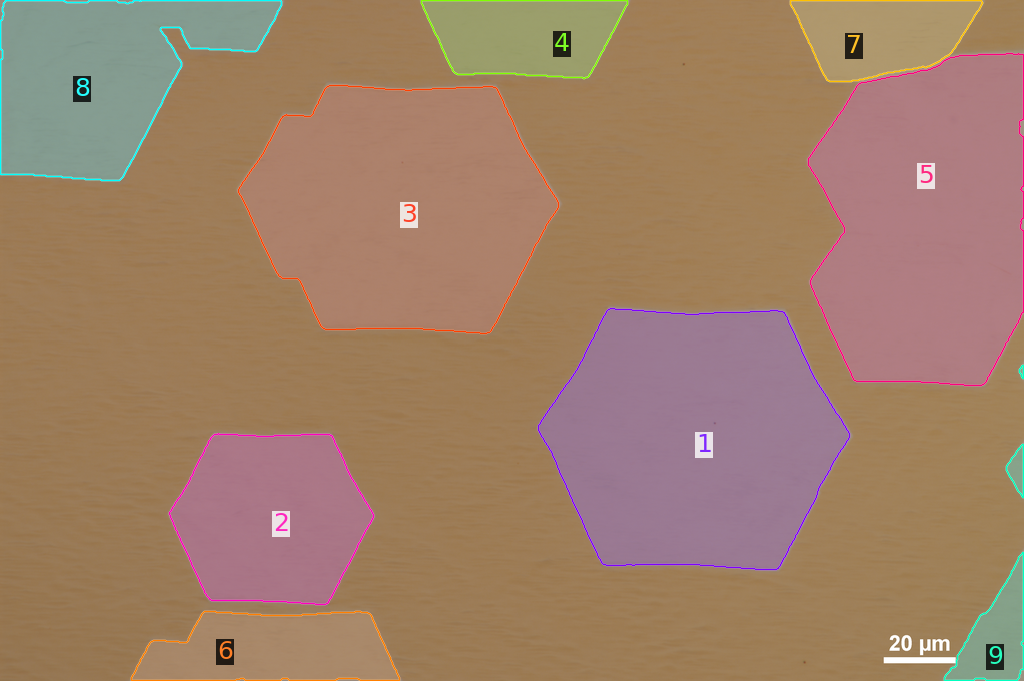

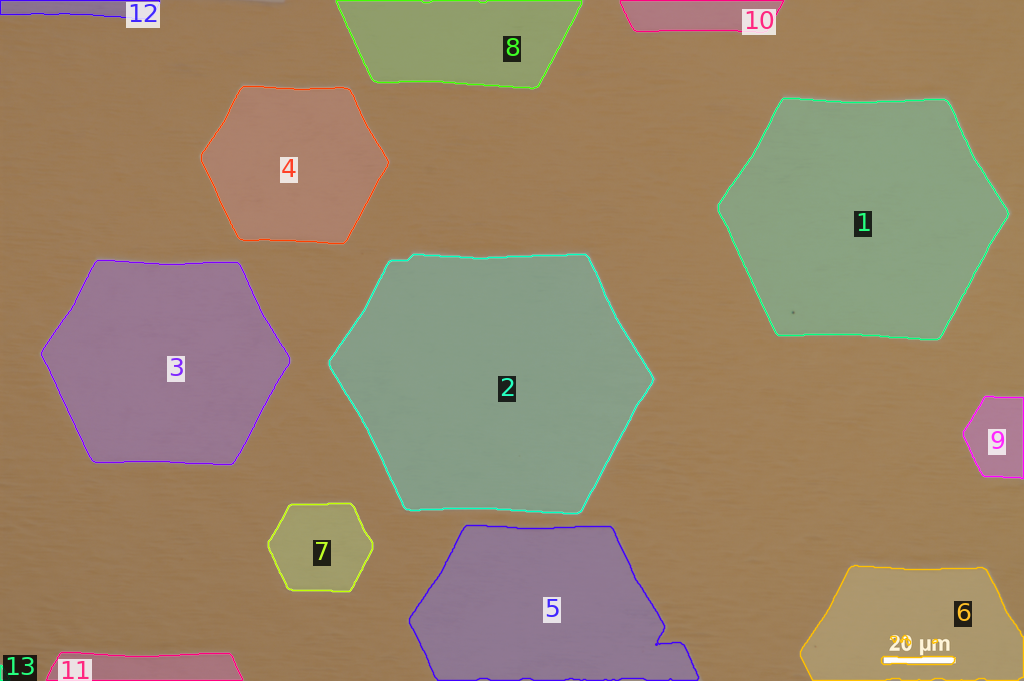

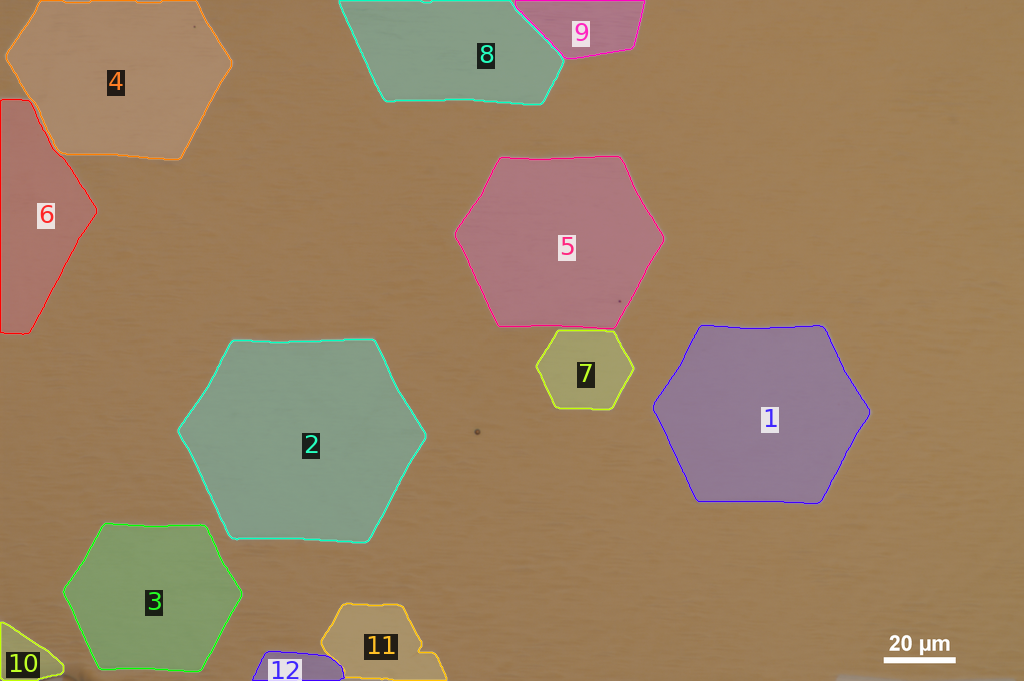

In [ ]:
gt_dataset, image_lookup = build_coco_ground_truth(LABEL_DIR, GT_JSON_PATH)
profile_df, predictions = run_batch_agent_inference(image_lookup)
PIXEL_DIR = RUN_DIR / "pixel_metrics"
PIXEL_SUMMARY_CSV_PATH = PIXEL_DIR / "metrics_summary.csv"
PIXEL_DIR.mkdir(parents=True, exist_ok=True)

with PREDICTIONS_JSON_PATH.open("w", encoding="utf-8") as handle:
    json.dump(predictions, handle, indent=2, ensure_ascii=False)

metrics = evaluate_coco_predictions(GT_JSON_PATH, PREDICTIONS_JSON_PATH)
pixel_metrics, pixel_df = compute_pixel_mask_metrics(gt_dataset, predictions, PIXEL_SUMMARY_CSV_PATH)
metrics.update(pixel_metrics)
metrics["pixel_dir"] = str(PIXEL_DIR)
metrics["pixel_summary_csv"] = str(PIXEL_SUMMARY_CSV_PATH)

profile_summary = save_profile_artifacts(
    profile_df=profile_df,
    profile_csv_path=PROFILE_CSV_PATH,
    profile_summary_json_path=PROFILE_SUMMARY_JSON_PATH,
    profile_time_plot=PROFILE_TIME_PLOT,
    profile_memory_plot=PROFILE_MEMORY_PLOT,
)
result_row = build_result_row(metrics, profile_summary, profile_df)
result_row = {column: result_row.get(column) for column in SUMMARY_COLUMNS}

metrics_payload = {
    "metrics": metrics,
    "pixel_metrics": pixel_metrics,
    "pixel_summary_csv": str(PIXEL_SUMMARY_CSV_PATH),
    "profile_summary": profile_summary,
    "result_row": result_row,
    "ground_truth_json": str(GT_JSON_PATH),
    "predictions_json": str(PREDICTIONS_JSON_PATH),
    "text_prompt": TEXT_PROMPT,
}
with METRICS_JSON_PATH.open("w", encoding="utf-8") as handle:
    json.dump(metrics_payload, handle, indent=2, ensure_ascii=False)

result_df = pd.DataFrame([result_row], columns=SUMMARY_COLUMNS)
display(result_df)
display(profile_df)
display(pixel_df)

if SHOW_IMAGE_VISUALIZATION:
    successful_visuals = [
        visual_path
        for visual_path in sorted(VIS_DIR.glob("*.png"))
        if visual_path.exists()
    ][:3]
    for visual_path in successful_visuals:
        display(Image(filename=str(visual_path)))

In [11]:
if APPEND_TO_SUMMARY_CSV:
    if SUMMARY_CSV_PATH.exists():
        summary_df = pd.read_csv(SUMMARY_CSV_PATH)
        summary_df = summary_df.reindex(columns=SUMMARY_COLUMNS)
    else:
        summary_df = pd.DataFrame(columns=SUMMARY_COLUMNS)
    new_row_df = pd.DataFrame([result_row], columns=SUMMARY_COLUMNS)
    summary_df = pd.concat([summary_df, new_row_df], ignore_index=True)
    summary_df.to_csv(SUMMARY_CSV_PATH, index=False)
    print(f"Appended 1 row to {SUMMARY_CSV_PATH}")
else:
    print("Set APPEND_TO_SUMMARY_CSV = True in the previous cell if you want to append the new row to assets/50x_unsup_summary.csv.")

result_df

Appended 1 row to assets/50x_unsup_summary.csv


,split,mode,model,coco/segm_mAP,coco/segm_mAP_50,coco/segm_mAP_75,coco/segm_mAP_s,coco/segm_mAP_m,coco/segm_mAP_l,time,...,median_time_ms,max_time_ms,mean_peak_allocated_mb,median_peak_allocated_mb,max_peak_allocated_mb,mean_peak_reserved_mb,median_peak_reserved_mb,max_peak_reserved_mb,num_images,num_warmup
0,50x_unsup,plain,sam3_agent_qwen3.5-flash,0.52322,0.60396,0.548207,0.0,0.466427,0.652034,18.696572,...,18638.435331,39584.656425,5011.789958,5088.915527,5088.915527,5327.666667,5328.0,5328.0,6,0
